In [5]:
import sympy
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from scipy.integrate import odeint
from scipy.optimize import root_scalar,minimize
import pandas as pd


In [2]:
## define symbolic variables
## a -- \alpha_C -- (scaled) basal transcription
## b -- \beta_C/\beta_X -- (scaled) regulatory activation strength
## c -- \bar{C} -- protein concentration 
## d -- \delta -- degradation/dilution rate
## n -- \eta_C -- Hill Coefficient

from sympy import diff
a,b,c,d,n = sympy.symbols('a b c d n')


FileNotFoundError: [Errno 2] No such file or directory: 'figs/figS7A_multistability_contours.svg'

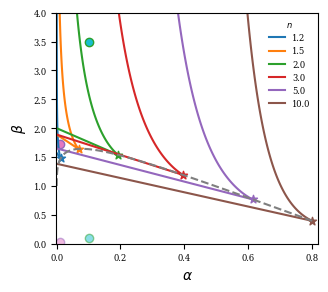

In [6]:
### strategy for plotting curves with fixed n:
### find the critical alpha/beta/concentration using the functions defined here
plt.rcParams['svg.fonttype']='none'
def beta_crit(n,d=1):
    return 4*n*d/(n-1)**((n-1)/n)/(n+1)**((n+1)/n)
def alpha_offset(n,db):
    return db*(n-1)/(2*n)
def alpha_crit(n,b):
    return b*((n-1)*(n-1)/(4*n))
def conc_crit(n):
    return ((n-1)/(n+1))**(1/n)
def peak_half_width(n,b_off,b):
    return 4/(b*(n*n-1))*np.sqrt(b_off/b*n*((n-1)/(n+1))**(3/n))
def beta_zero(n):
    return n/(n-1)**((n-1)/n)

fpc = a + b*c**n / (1 +c**n) - d*c
der_fpc = diff(fpc,c)
der2_fpc = diff(der_fpc,c)
fig,ax = plt.subplots(1,1,figsize=(3.375,3))
leg_hndl_l = []
leg_lbl_l = []
for iii,nnn in enumerate([1.2,1.5,2,3,5,10]):
    ab_pts_l = []
    c_star = conc_crit(nnn)
    b_star = beta_crit(nnn)
    a_star = alpha_crit(nnn,b_star)
    max_beta_offset = 2*nnn/(nnn-1)*a_star
    b_zero = beta_zero(nnn)
    lb_xvals = np.linspace(0,a_star)
    lb_yvals = (b_star-b_zero)/a_star * lb_xvals + b_zero
    lb_l2d = ax.plot(lb_xvals,lb_yvals,color=f'C{iii:d}')
    ### incrementally increase beta and use root finding to obtain the C+gamma/C-gamma 
    for zzz,b_off in enumerate(np.linspace(0,4-b_star,101)[1:-1]):
        dc = peak_half_width(nnn,b_off,b_star)
        a_off = alpha_offset(nnn,b_off)
        # if a_star-a_off > 0: max a is a_star-a_off + amax
        fpc_expr = fpc.subs([(a,max(a_star-a_off,0)),(b,b_star+b_off),(d,1),(n,nnn)])
        der_fpc_expr = der_fpc.subs([(b,b_star+b_off),(d,1),(n,nnn)])
        der2_fpc_expr = der2_fpc.subs([(b,b_star+b_off),(d,1),(n,nnn)])
        fpc_func = sympy.lambdify(c,fpc_expr,"numpy")
        der_fpc_func = sympy.lambdify(c,der_fpc_expr,"numpy")
        der2_fpc_func = sympy.lambdify(c,der2_fpc_expr,"numpy")
        ### formulate the expression as a function of alpha and increase (C-gamma) or decrease (C+gamma) until the curve is found
        root_minus = root_scalar(der_fpc_func,x0=c_star-dc,bracket=(0,c_star),method='toms748')
        root_plus = root_scalar(der_fpc_func,x0=c_star+dc,bracket=(c_star,c_star+10*dc),method='toms748')
        ## additional code to calculate the bottom curve
        ## if -1*fpc_func(root_minus.root) < a_star-a_off: -1*fpc_func(root_minus.root)
        a_max = max(a_star-a_off,0)-1*fpc_func(root_minus.root)
        #a_min = max(a_star-a_off-fpc_func(root_plus.root),0)
        ab_pts_l.extend([(a_max,b_star+b_off)])
        #root_minus = minimize(expr1_func,x0=max(c_star-dc,0),bounds=[(max(c_star-1.5*dc,0),c_star)],method='Nelder-Mead')
        #root_plus = minimize(negexpr1_func,x0=c_star+dc,bounds=[(c_star,c_star+1.5*dc)],method='Nelder-Mead')
        ### save the points as ordered pairs
        # if root_minus.fun<0 and root_plus.fun<0:
        #     a_min = max(a_star - a_off + root_plus.fun,0)
        #     a_max = a_star - a_off - root_minus.fun
        #     ab_pts_l.extend([(a_max,b_star+b_off)])
            # ab_pts_l.extend([(a_min,b_star+b_off),(a_max,b_star+b_off)])
        # else:
            #print(f"One fixed point for all nonzero values of alpha at {b_off:.3f}")
            #ab_pts_l.append((0,b_star+b_off))
            # pass
    alpha_l,beta_l = zip(*sorted(ab_pts_l,key=lambda x: x[0]))
    alpha_arr = np.asarray(alpha_l)
    beta_arr = np.asarray(beta_l)
    sel = alpha_arr>1e-9
    alpha_arr = alpha_arr[sel]
    beta_arr = beta_arr[sel]
    ub_l2d, = ax.plot(np.r_[alpha_arr,a_star],np.r_[beta_arr,b_star],color=f'C{iii:d}')#,label=f'{nnn:.1f}')
    leg_hndl_l.append(ub_l2d)
    leg_lbl_l.append(f'{nnn:.1f}')
    ax.scatter([a_star],[b_star],marker='*',color=f'C{iii:d}')


beta_vals = beta_crit(np.logspace(0,1,101))
alpha_vals = alpha_crit(np.logspace(0,1,101),beta_vals)
ax.plot(alpha_vals,beta_vals,color='C7',ls='--')
ax.set_xlabel(r'$\alpha$',family='serif')
ax.set_ylabel(r'$\beta$',family='serif')
ax.set_ylim(0,4)
ax.set_xlim(-0.001,0.82)
ax.scatter([0.1],[3.5],color='C9',edgecolor='C2')
ax.scatter([0.1],[0.1],color='C9',edgecolor='C2',alpha=0.5)
ax.scatter([0.01],[2.5*0.69],color='C6',edgecolor='C4')
ax.scatter([0.01],[2.5*0.01],color='C6',edgecolor='C4',alpha=0.5)
plt.setp(ax.get_xticklabels(),size=6,family='serif')
plt.setp(ax.get_yticklabels(),size=6,family='serif')
leg = ax.legend(leg_hndl_l,leg_lbl_l,ncol=1,prop={'size':6,'family':'serif'},frameon=False,title=r'$n$',title_fontproperties={'size':6,'family':'serif'})

fig.savefig('figs/figS7A_multistability_contours.svg')

FileNotFoundError: [Errno 2] No such file or directory: 'figs/figS7B_concentration_dynamics.svg'

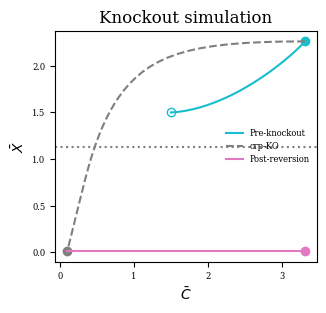

In [7]:

tvals = np.linspace(0,100,1001)
def conc_dyn(c_vec,t,a,b,n,a2,b2,n2,d):
    return (a + b*c_vec[0]**n / (1 +c_vec[0]**n) - d*c_vec[0], a2 + c_vec[0]**n / (1 +c_vec[0]**n)* b2*c_vec[1]**n2 / (1 +c_vec[1]**n2)-d*c_vec[1])

conc_time_highIC = odeint(conc_dyn,[1.5,1.5],tvals,args=(0.1,3.5,2,0.01,2.5,5,1))
KO_time = odeint(conc_dyn,conc_time_highIC[-1],tvals,args=(0.1,0.1,2,0.01,2.5,5,1))
conc_time_lowIC = odeint(conc_dyn,KO_time[-1],tvals,args=(0.1,3.5,2,0.01,2.5,5,1))

fig,ax = plt.subplots(1,1,figsize=(3.375,3))
ax.plot(conc_time_highIC[:,0],conc_time_highIC[:,1],color='C9', label='Pre-knockout')
ax.plot(KO_time[:,0],KO_time[:,1],ls='--', color='C7', label='crp-KO') 
ax.plot(conc_time_lowIC[:,0],conc_time_lowIC[:,1],color='C6',label='Post-reversion')
ax.legend(ncol=1,prop={'size':6,'family':'serif'},frameon=False)
ax.scatter(conc_time_highIC[0,0],conc_time_highIC[0,1],color='w',edgecolor='C9')
ax.scatter(conc_time_highIC[-1,0],conc_time_highIC[-1,1],color='C9')
ax.scatter(KO_time[-1,0],KO_time[-1,1],color='C7')
ax.scatter(conc_time_lowIC[-1,0],conc_time_lowIC[-1,1],color='C6')
ax.axhline(1.1325472373527172,ls=':',color='C7')
#ax.plot(tvals,np.ones(tvals.shape[0])*0.8336243676268291,color='C7',ls='--')
#ax.plot(tvals,np.ones(tvals.shape[0])*1.812348139532157,color='C0',ls='--')
#ax.plot(tvals,np.ones(tvals.shape[0])*0.1021281593309971,color='C1',ls='--')
ax.set_xlabel(r'$\bar{C}$',family='serif')
ax.set_ylabel(r'$\bar{X}$',family='serif')
plt.setp(ax.get_xticklabels(),size=6,family='serif')
plt.setp(ax.get_yticklabels(),size=6,family='serif')
ax.set_title('Knockout simulation',family='serif')
fig.savefig('figs/figS7B_concentration_dynamics.svg')